In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('train.csv')
data.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [3]:
data.sample(10)

,id,carat,cut,color,clarity,depth,table,x,y,z,price
47019,47019,0.40,Ideal,F,VS2,61.3,57.0,4.75,4.79,2.92,896
53559,53559,0.70,Very Good,F,SI1,61.5,57.0,5.67,5.73,3.50,2409
50213,50213,0.36,Ideal,E,VVS2,61.4,57.0,4.62,4.59,2.83,929
27984,27984,1.52,Very Good,I,SI1,61.5,60.0,7.38,7.32,4.52,8736
27796,27796,1.20,Ideal,D,VS2,62.1,56.0,6.79,6.83,4.23,8451
81431,81431,1.53,Ideal,H,SI1,61.9,55.0,7.38,7.41,4.58,10063
124528,124528,0.31,Ideal,I,VS1,61.4,57.0,4.38,4.35,2.69,559
9697,9697,0.52,Ideal,F,VS2,62.2,56.0,5.17,5.12,3.20,1605
5732,5732,0.38,Very Good,D,SI1,58.9,61.0,4.74,4.77,2.79,862
91278,91278,0.81,Ideal,H,VS2,61.7,55.0,5.93,5.96,3.66,3230


In [4]:
data.isnull().sum()

id         0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [5]:
data.shape

(193573, 11)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  object 
 3   color    193573 non-null  object 
 4   clarity  193573 non-null  object 
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 16.2+ MB


In [7]:
data.size

2129303

In [8]:
data.columns

Index(['id', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y',
       'z', 'price'],
      dtype='object')

In [9]:
data['cut'].value_counts()

cut
Ideal        92454
Premium      49910
Very Good    37566
Good         11622
Fair          2021
Name: count, dtype: int64

In [10]:
data['color'].value_counts()

color
G    44391
E    35869
F    34258
H    30799
D    24286
I    17514
J     6456
Name: count, dtype: int64

In [11]:
data = data.drop('id', axis=1)

In [12]:
data.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
cat_columns = data.columns[data.dtypes == 'object']
cat_columns

Index(['cut', 'color', 'clarity'], dtype='object')

In [15]:
num_columns = data.columns[data.dtypes != 'object']
num_columns

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'price'], dtype='object')

In [16]:
data[num_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   carat   193573 non-null  float64
 1   depth   193573 non-null  float64
 2   table   193573 non-null  float64
 3   x       193573 non-null  float64
 4   y       193573 non-null  float64
 5   z       193573 non-null  float64
 6   price   193573 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 10.3 MB


<Axes: >

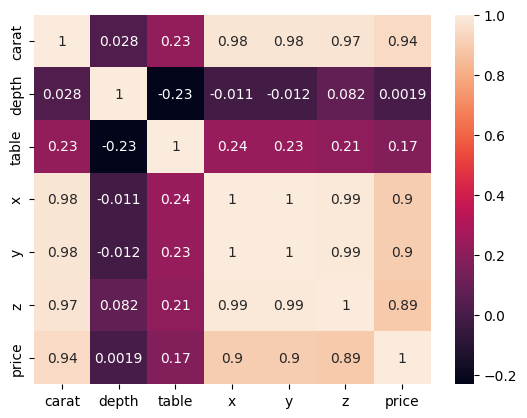

In [17]:
import seaborn as sns
sns.heatmap(data[num_columns].corr(),annot=True)

In [18]:
cut_map={'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
clarity_map={'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5, 'VVS2':6, 'VVS1':7, 'IF':8}
color_map={'D':1, 'E':2, 'F':3, "G":4, "H":5, 'I':6, 'J':7} 

In [19]:
data['cut'] = data['cut'].map(cut_map)
data['clarity']=data['clarity'].map(clarity_map)
data['color']=data['color'].map(color_map)

In [20]:
data

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,4,3,4,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,3,7,2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,5,4,5,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,5,4,5,61.6,56.0,4.38,4.41,2.71,666
4,1.70,4,4,4,62.6,59.0,7.65,7.61,4.77,14453
...,...,...,...,...,...,...,...,...,...,...
193568,0.31,5,1,6,61.1,56.0,4.35,4.39,2.67,1130
193569,0.70,4,4,6,60.3,58.0,5.75,5.77,3.47,2874
193570,0.73,3,3,3,63.1,57.0,5.72,5.75,3.62,3036
193571,0.34,3,1,3,62.9,55.0,4.45,4.49,2.81,681


In [21]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
##pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [22]:
X=data.drop('price', axis=1)
y=data['price']

In [23]:
X

,carat,cut,color,clarity,depth,table,x,y,z
0,1.52,4,3,4,62.2,58.0,7.27,7.33,4.55
1,2.03,3,7,2,62.0,58.0,8.06,8.12,5.05
2,0.70,5,4,5,61.2,57.0,5.69,5.73,3.50
3,0.32,5,4,5,61.6,56.0,4.38,4.41,2.71
4,1.70,4,4,4,62.6,59.0,7.65,7.61,4.77
...,...,...,...,...,...,...,...,...,...
193568,0.31,5,1,6,61.1,56.0,4.35,4.39,2.67
193569,0.70,4,4,6,60.3,58.0,5.75,5.77,3.47
193570,0.73,3,3,3,63.1,57.0,5.72,5.75,3.62
193571,0.34,3,1,3,62.9,55.0,4.45,4.49,2.81


In [24]:
y

0         13619
1         13387
2          2772
3           666
4         14453
          ...  
193568     1130
193569     2874
193570     3036
193571      681
193572     2258
Name: price, Length: 193573, dtype: int64

In [25]:
cat_cols = X.select_dtypes(include="object").columns

num_cols = X.select_dtypes(exclude='object').columns

In [26]:
cat_cols

Index([], dtype='object')

In [27]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer()),
        ('scaler', StandardScaler())
    ]
)

In [28]:
cut_categories={'Fair', 'Good', 'Very Good', 'Premium', 'Ideal'}
clarity_categories={'I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'}
color_categories={'D', 'E', 'F', "G", "H", 'I', 'J'} 

In [29]:
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinalencoder', OrdinalEncoder(categories=[cut_categories, 
                                                      color_categories,
                                                      clarity_categories]))
    ]
)

In [30]:
preprocessor= ColumnTransformer(

    [
        ('num_pipeline', num_pipeline, num_cols),
        ('cat_pipeline', cat_pipeline, cat_cols)
    ]
)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=100)

In [32]:
X_train.shape

(135501, 9)

In [33]:
type(X_train)

pandas.core.frame.DataFrame

In [34]:
preprocessor.fit_transform(X_train)

array([[ 0.23569933, -1.13817621, -0.93169454, ...,  0.3729747 ,
         0.398285  ,  0.48862954],
       [-0.15355261, -0.13264722,  0.29894275, ...,  0.10248   ,
         0.06250482, -0.09456783],
       [-0.9536816 , -1.13817621,  1.52958004, ..., -1.08769667,
        -1.08096284, -1.1005833 ],
       ...,
       [ 0.94932789, -0.13264722,  1.52958004, ...,  1.004129  ,
         1.03354481,  1.07182691],
       [-1.06180714, -2.1437052 ,  0.29894275, ..., -1.31310892,
        -1.30784134, -1.21722278],
       [-0.82393096,  0.87288177,  0.29894275, ..., -0.83523495,
        -0.86315947, -0.89646422]], shape=(135501, 9))